Saving complete_renewable_energy_dataset.csv to complete_renewable_energy_dataset.csv
Uploaded file: complete_renewable_energy_dataset.csv

First 5 rows:
     Country  Year Energy Type  Production (GWh)  Installed Capacity (MW)  \
0        USA  2011       Solar      85404.690027              5549.794323   
1  Australia  2008  Geothermal      22205.069382             43211.593798   
2     Canada  2013     Biomass      94102.732038              6139.117212   
3      Japan  2010     Biomass      88771.932910             40323.639260   
4      China  2018       Solar      93288.408581             30755.403056   

   Investments (USD)  Population           GDP  Energy Consumption  \
0       5.604125e+09  1064007213  1.775278e+14       369654.644184   
1       6.361886e+08  1033255852  6.435372e+13       771781.636293   
2       6.158680e+09    14895124  1.567926e+14       342707.152899   
3       8.526116e+09  1448827283  1.350464e+14       498839.574253   
4       5.086237e+09  1499494307 

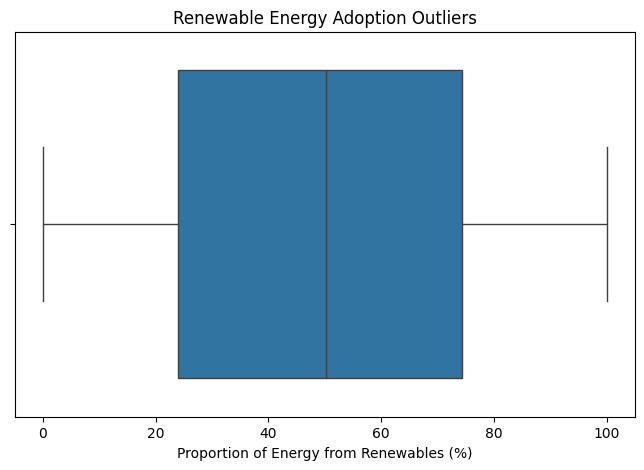


Scaled Renewable Energy Adoption:
   Proportion of Energy from Renewables
0                              0.258858
1                              0.950129
2                              0.673513
3                              0.337356
4                              0.595025

Encoded Categorical Columns:
   Country  Energy Type
0        9            3
1        0            1
2        2            0
3        7            0
4        3            3

Energy Type One-Hot Encoded:
   Energy_Type_0  Energy_Type_1  Energy_Type_2  Energy_Type_3  Energy_Type_4
0          False          False          False           True          False
1          False           True          False          False          False
2           True          False          False          False          False
3           True          False          False          False          False
4          False          False          False           True          False

Final Dataset Shape:
(2500, 61)

Final Dataset Information

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# GLOBAL RENEWABLE ENERGY ADOPTION
# DATA CLEANING AND PREPROCESSING
# ============================================================


# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from google.colab import files


# ------------------------------------------------------------
# 2. UPLOAD DATASET
# ------------------------------------------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Uploaded file:", filename)


# ------------------------------------------------------------
# 3. READ CSV DATASET
# ------------------------------------------------------------

df = pd.read_csv(filename)

print("\nFirst 5 rows:")
print(df.head())


# ------------------------------------------------------------
# 4. DATASET SHAPE AND INFORMATION
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()


# ------------------------------------------------------------
# 5. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
print(df.describe(include='all'))


# ------------------------------------------------------------
# 6. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 7. HANDLE MISSING VALUES
# ------------------------------------------------------------

# Select numerical columns

numeric_cols = df.select_dtypes(
    include=np.number
).columns


# Replace missing numerical values
# with the median

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)


print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 8. CHECK DUPLICATE ROWS
# ------------------------------------------------------------

print(
    "\nDuplicate Rows:",
    df.duplicated().sum()
)


# Remove duplicate rows

df.drop_duplicates(
    inplace=True
)


print(
    "Dataset Shape After Duplicate Removal:",
    df.shape
)


# ------------------------------------------------------------
# 9. CHECK OUTLIERS
# ------------------------------------------------------------

# Target variable:
# Proportion of Energy from Renewables

target = "Proportion of Energy from Renewables"


# Check whether target exists

if target in df.columns:

    Q1 = df[target].quantile(0.25)

    Q3 = df[target].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR


    outliers = df[
        (df[target] < lower) |
        (df[target] > upper)
    ]


    print("\nRenewable Energy Adoption Outliers:")
    print(outliers.head())

    print(
        "\nNumber of outliers:",
        len(outliers)
    )

else:

    print(
        "\nTarget column not found:"
        , target
    )


# ------------------------------------------------------------
# 10. VISUALIZE OUTLIERS
# ------------------------------------------------------------

if target in df.columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=df[target]
    )

    plt.title(
        "Renewable Energy Adoption Outliers"
    )

    plt.xlabel(
        "Proportion of Energy from Renewables (%)"
    )

    plt.show()


# ------------------------------------------------------------
# 11. NORMALIZATION / SCALING
# ------------------------------------------------------------

# Scale renewable energy adoption
# between 0 and 1

if target in df.columns:

    scaler = MinMaxScaler()

    df[[target]] = scaler.fit_transform(
        df[[target]]
    )


    print(
        "\nScaled Renewable Energy Adoption:"
    )

    print(
        df[[target]].head()
    )


# ------------------------------------------------------------
# 12. LABEL ENCODING
# ------------------------------------------------------------

encoder = LabelEncoder()


# Categorical columns relevant to
# renewable energy analysis

categorical_columns = [
    "Country",
    "Energy Type"
]


# Encode only columns that exist

categorical_columns = [
    col for col in categorical_columns
    if col in df.columns
]


for col in categorical_columns:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )


print(
    "\nEncoded Categorical Columns:"
)

if len(categorical_columns) > 0:

    print(
        df[categorical_columns].head()

    )


# ------------------------------------------------------------
# 13. ONE-HOT ENCODING
# ------------------------------------------------------------

# Create one-hot encoded columns
# for Energy Type

if "Energy Type" in df.columns:

    energy_type_dummies = pd.get_dummies(
        df["Energy Type"],
        prefix="Energy_Type"
    )


    df = pd.concat(
        [
            df,
            energy_type_dummies
        ],
        axis=1
    )


    print(
        "\nEnergy Type One-Hot Encoded:"
    )

    print(
        energy_type_dummies.head()
    )


# ------------------------------------------------------------
# 14. CONVERT DATE/YEAR IF REQUIRED
# ------------------------------------------------------------

# If Year exists, make sure it is numeric

if "Year" in df.columns:

    df["Year"] = pd.to_numeric(
        df["Year"],
        errors="coerce"
    )

    df["Year"] = df["Year"].fillna(
        df["Year"].median()
    )


# ------------------------------------------------------------
# 15. FINAL DATASET INFORMATION
# ------------------------------------------------------------

print(
    "\nFinal Dataset Shape:"
)

print(
    df.shape
)


print(
    "\nFinal Dataset Information:"
)

df.info()


# ------------------------------------------------------------
# 16. FINAL MISSING VALUE CHECK
# ------------------------------------------------------------

print(
    "\nFinal Missing Values:"
)

print(
    df.isnull().sum()
)


# ------------------------------------------------------------
# 17. SAVE CLEANED DATASET
# ------------------------------------------------------------

output_file = (
    "/content/"
    "Global_Renewable_Energy_Dataset_cleaned.csv"
)


df.to_csv(
    output_file,
    index=False
)


print(
    "\nCleaned dataset saved successfully!"
)

print(
    "File:",
    output_file
)


# ------------------------------------------------------------
# 18. DOWNLOAD CLEANED DATASET
# ------------------------------------------------------------

files.download(
    output_file
)